# Section 2 — Listed CLO closed-end funds: the sentiment gauge

Thin driver notebook: all logic lives in `src/cef/`.

- **Prices**: full history via yfinance.
- **NAV proxy**: these tickers are classified as plain equity on Yahoo, so `navPrice` (which worked for Section 1's ETFs) isn't populated — `bookValue` is used instead, clearly labeled as a quarterly accounting proxy, not the funds' own monthly NAV estimates.
- **Distributions**: full real dividend history via yfinance — the strongest exhibit in this section, no data-availability caveats.
- **Portfolio**: SEC EDGAR NPORT-P filings (structured XML), not the HTML N-CSR tables the mission brief suggested — more reliable, same underlying disclosure. CLO positions are tagged by the `assetCat == "ABS-CBDO"` field where present, with a name/title regex fallback for filers (e.g. OXLC) that leave it blank.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.cef import (
    scrape_prices_nav, scrape_filings,
    analysis_premium_discount, analysis_distributions, analysis_portfolio, analysis_equity_beta,
    viz_sentiment, viz_navprice, viz_portfolio,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_prices_nav.run()
    scrape_filings.run()

## Analysis (interim -> final)

In [3]:
premium_discount = analysis_premium_discount.run()
distributions = analysis_distributions.run()
portfolio = analysis_portfolio.run()
equity_beta = analysis_equity_beta.run()

book-value history has only 1 distinct date(s); need ~30 for a stable vol ratio. Run scrape_prices_nav.py again on more days.


## Viz (final -> figures/)

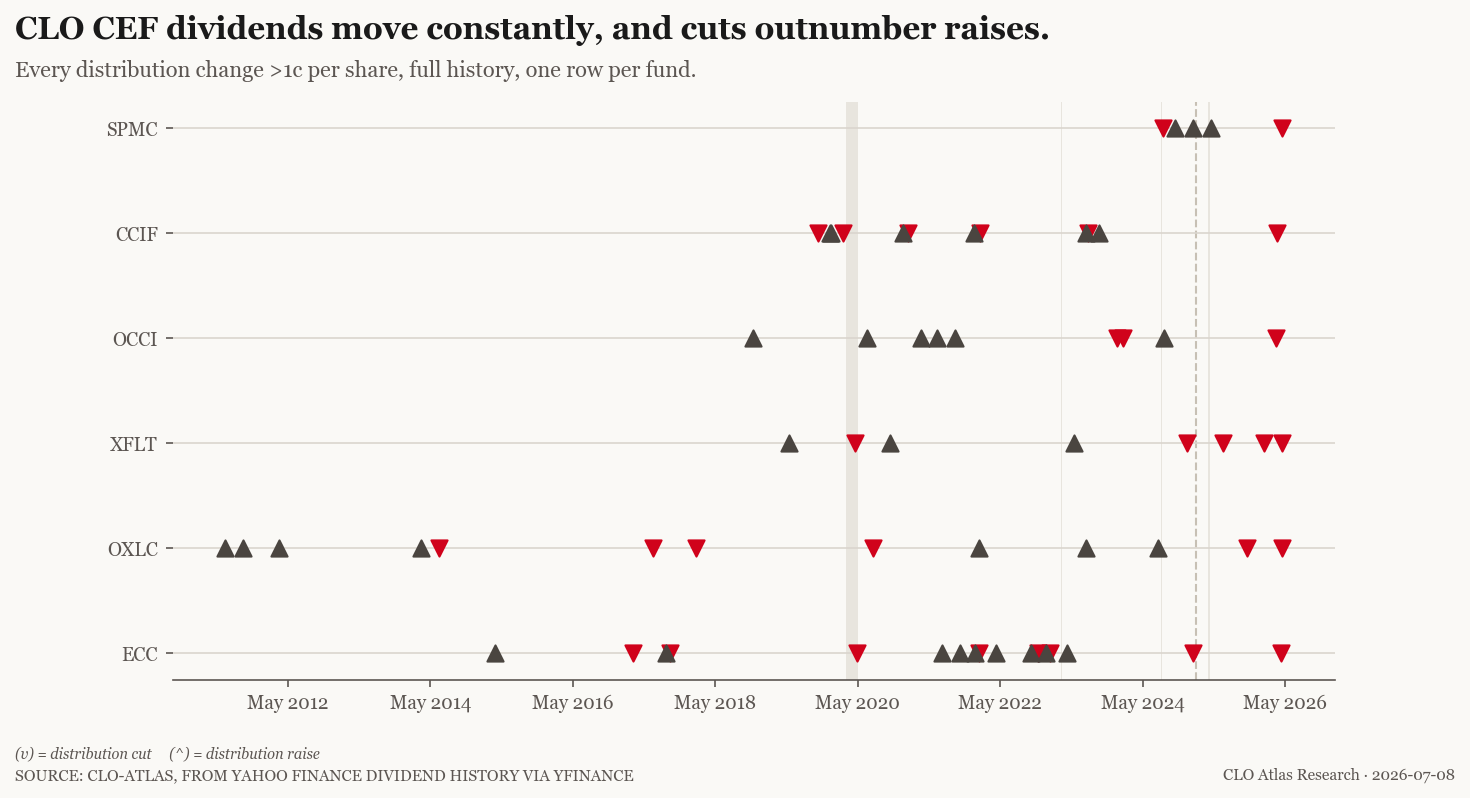

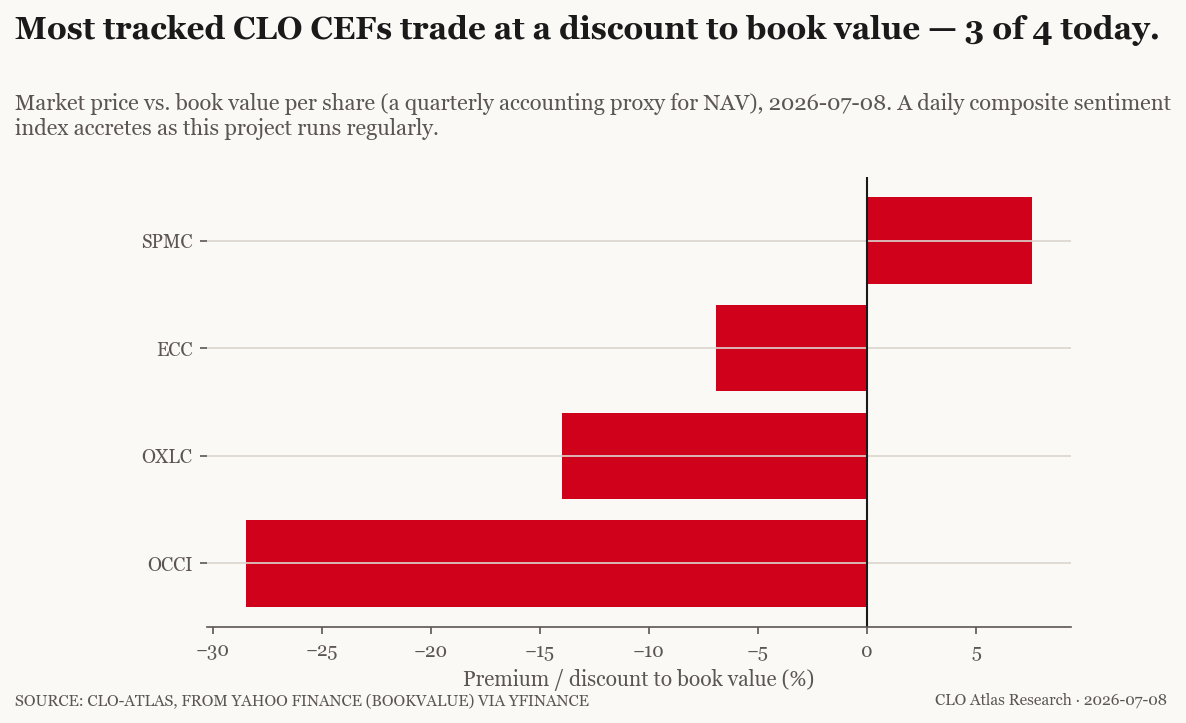

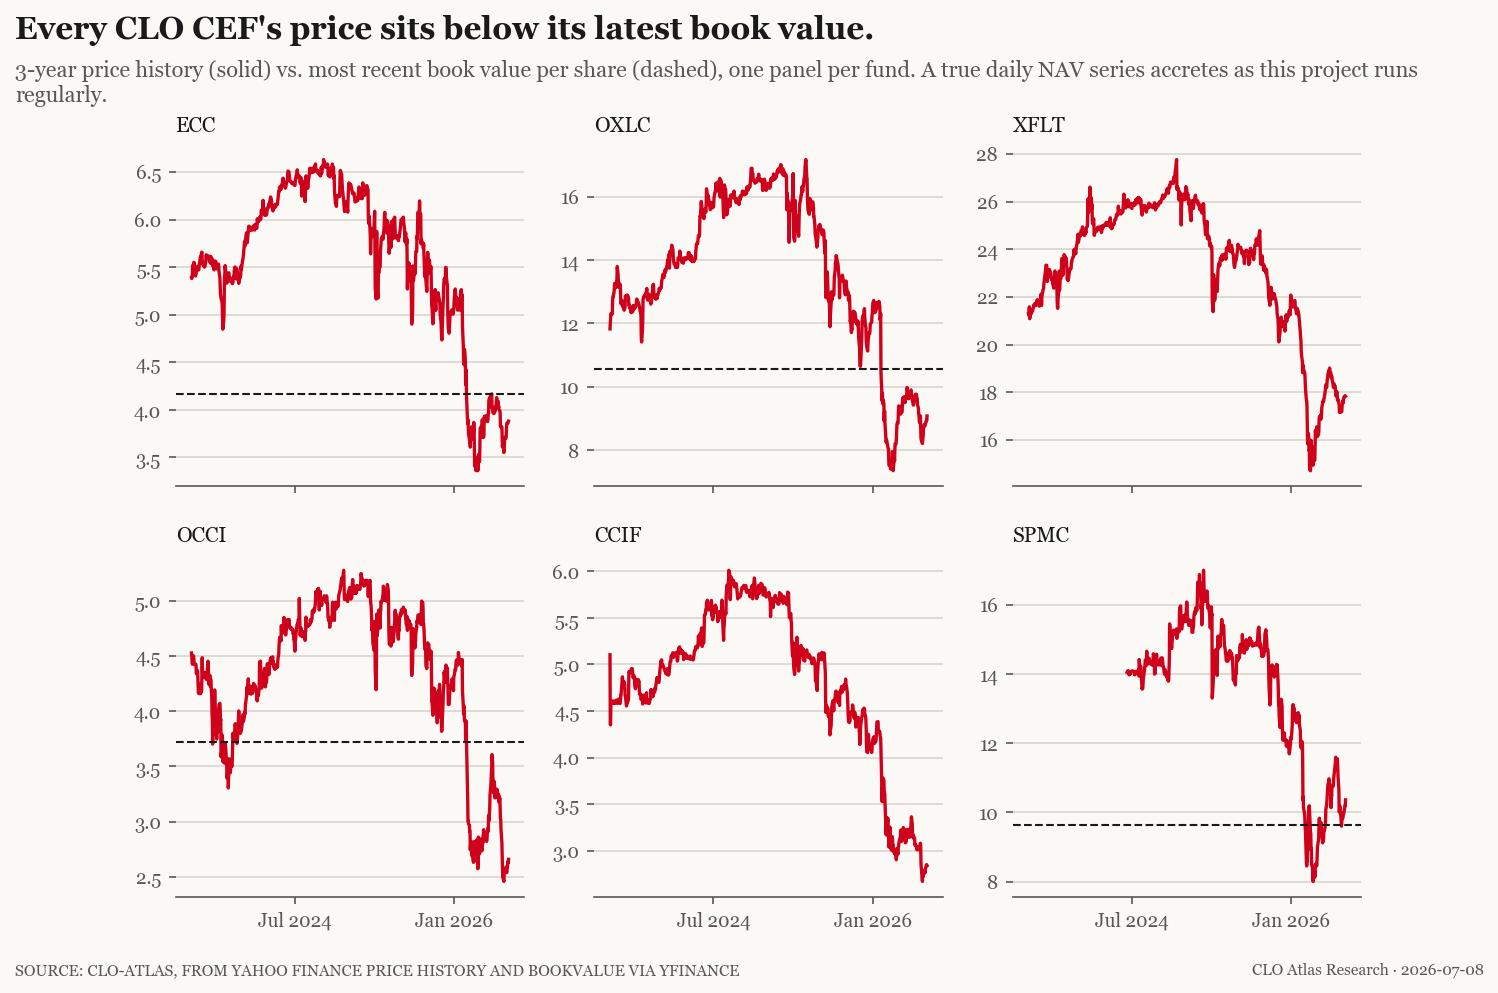

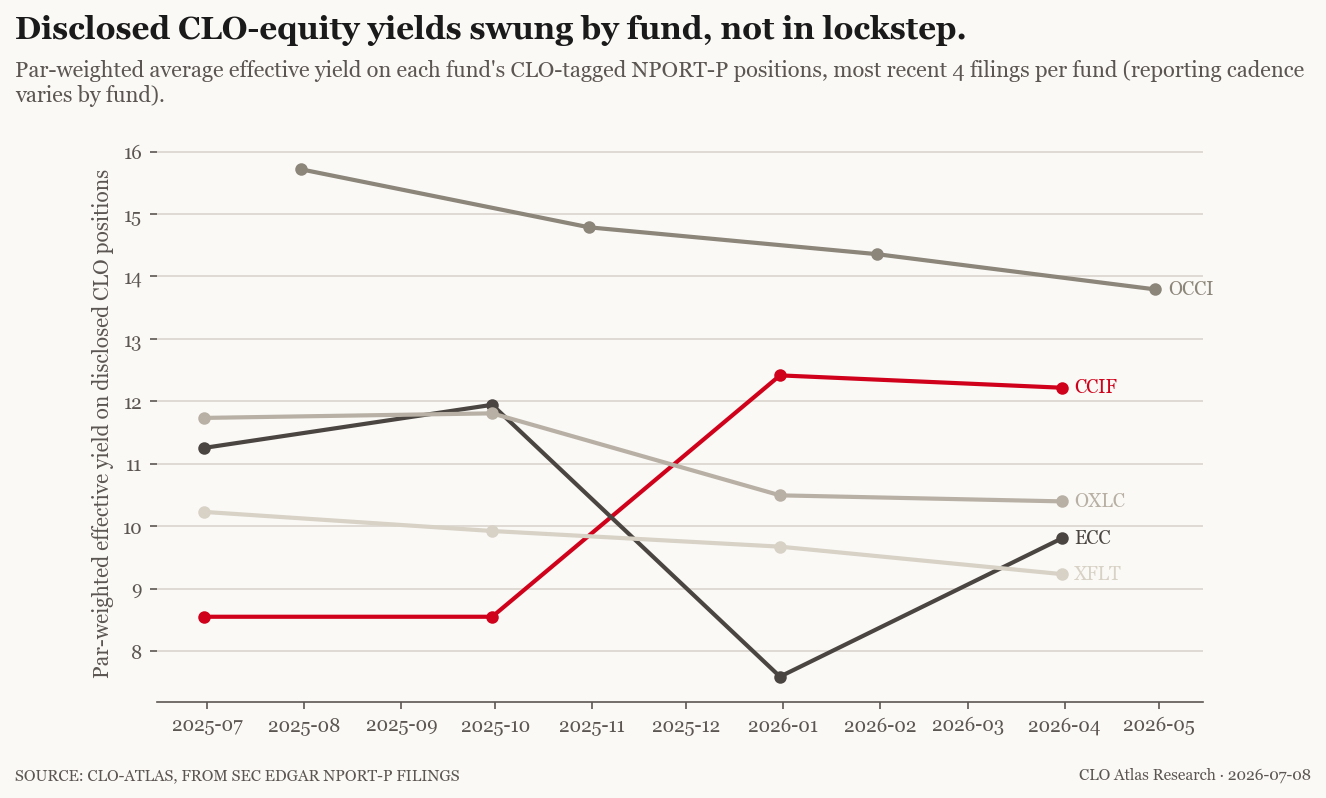

In [4]:
viz_sentiment.run()
viz_navprice.run()
viz_portfolio.run()

## Exhibits

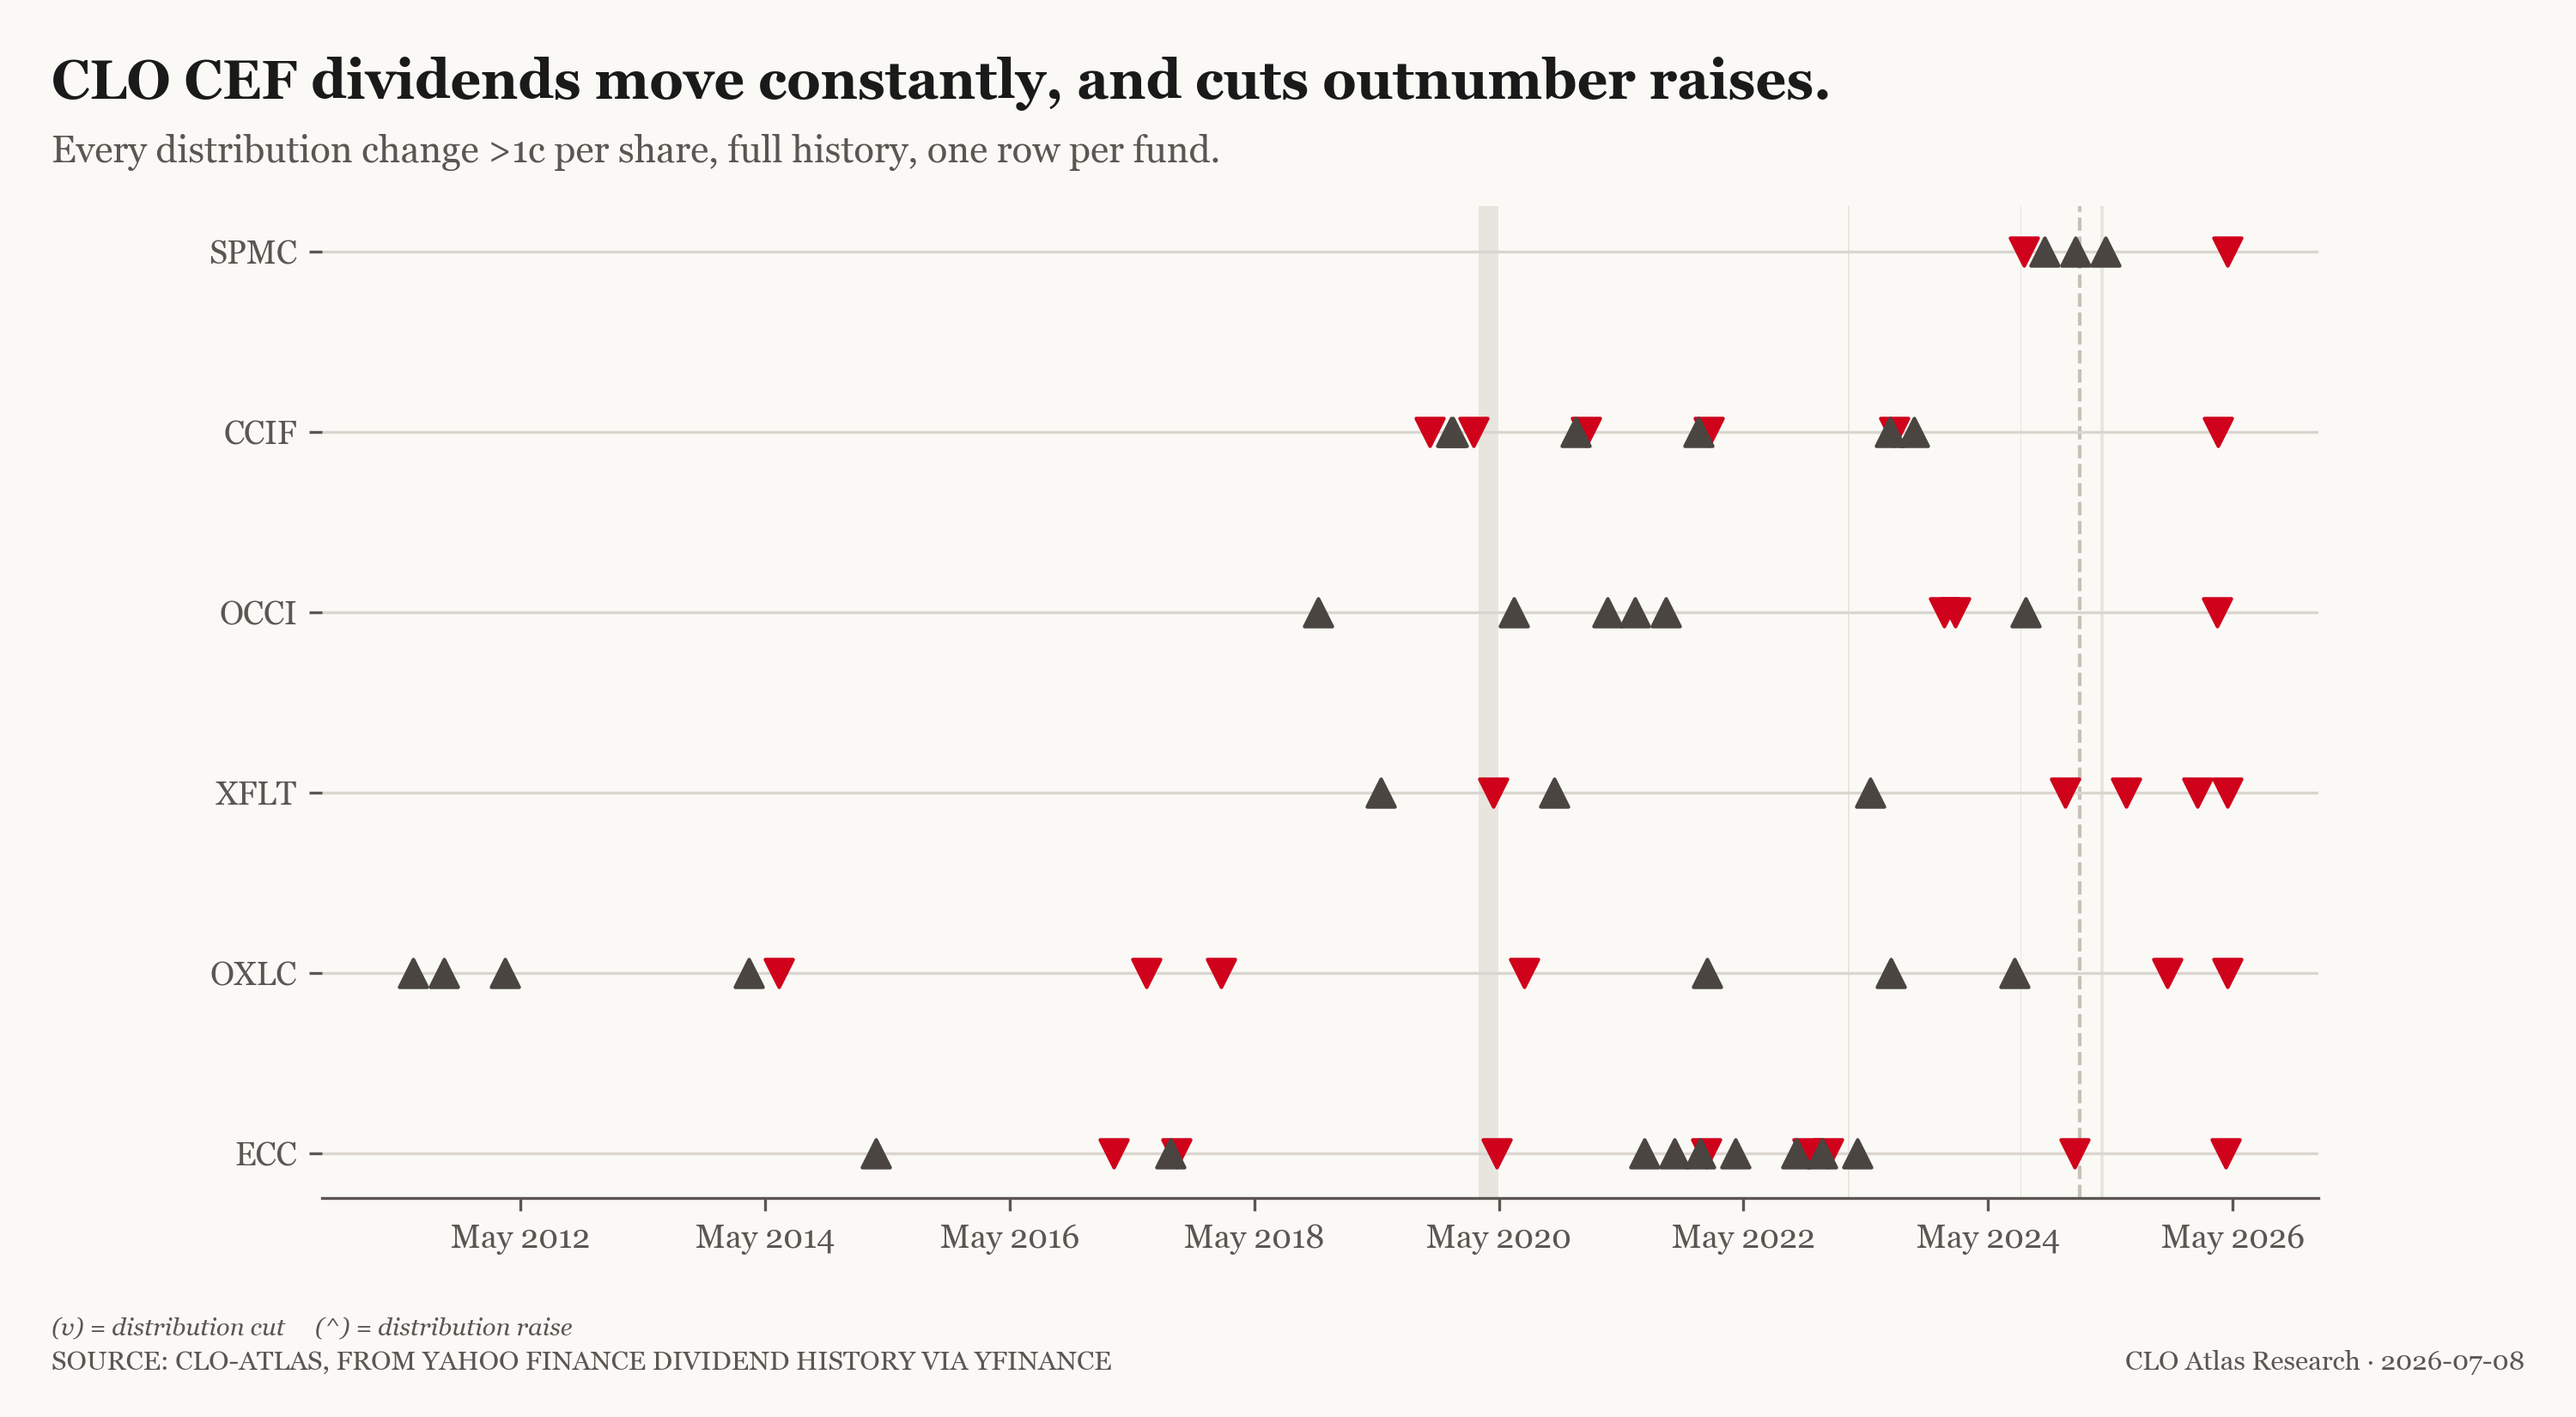

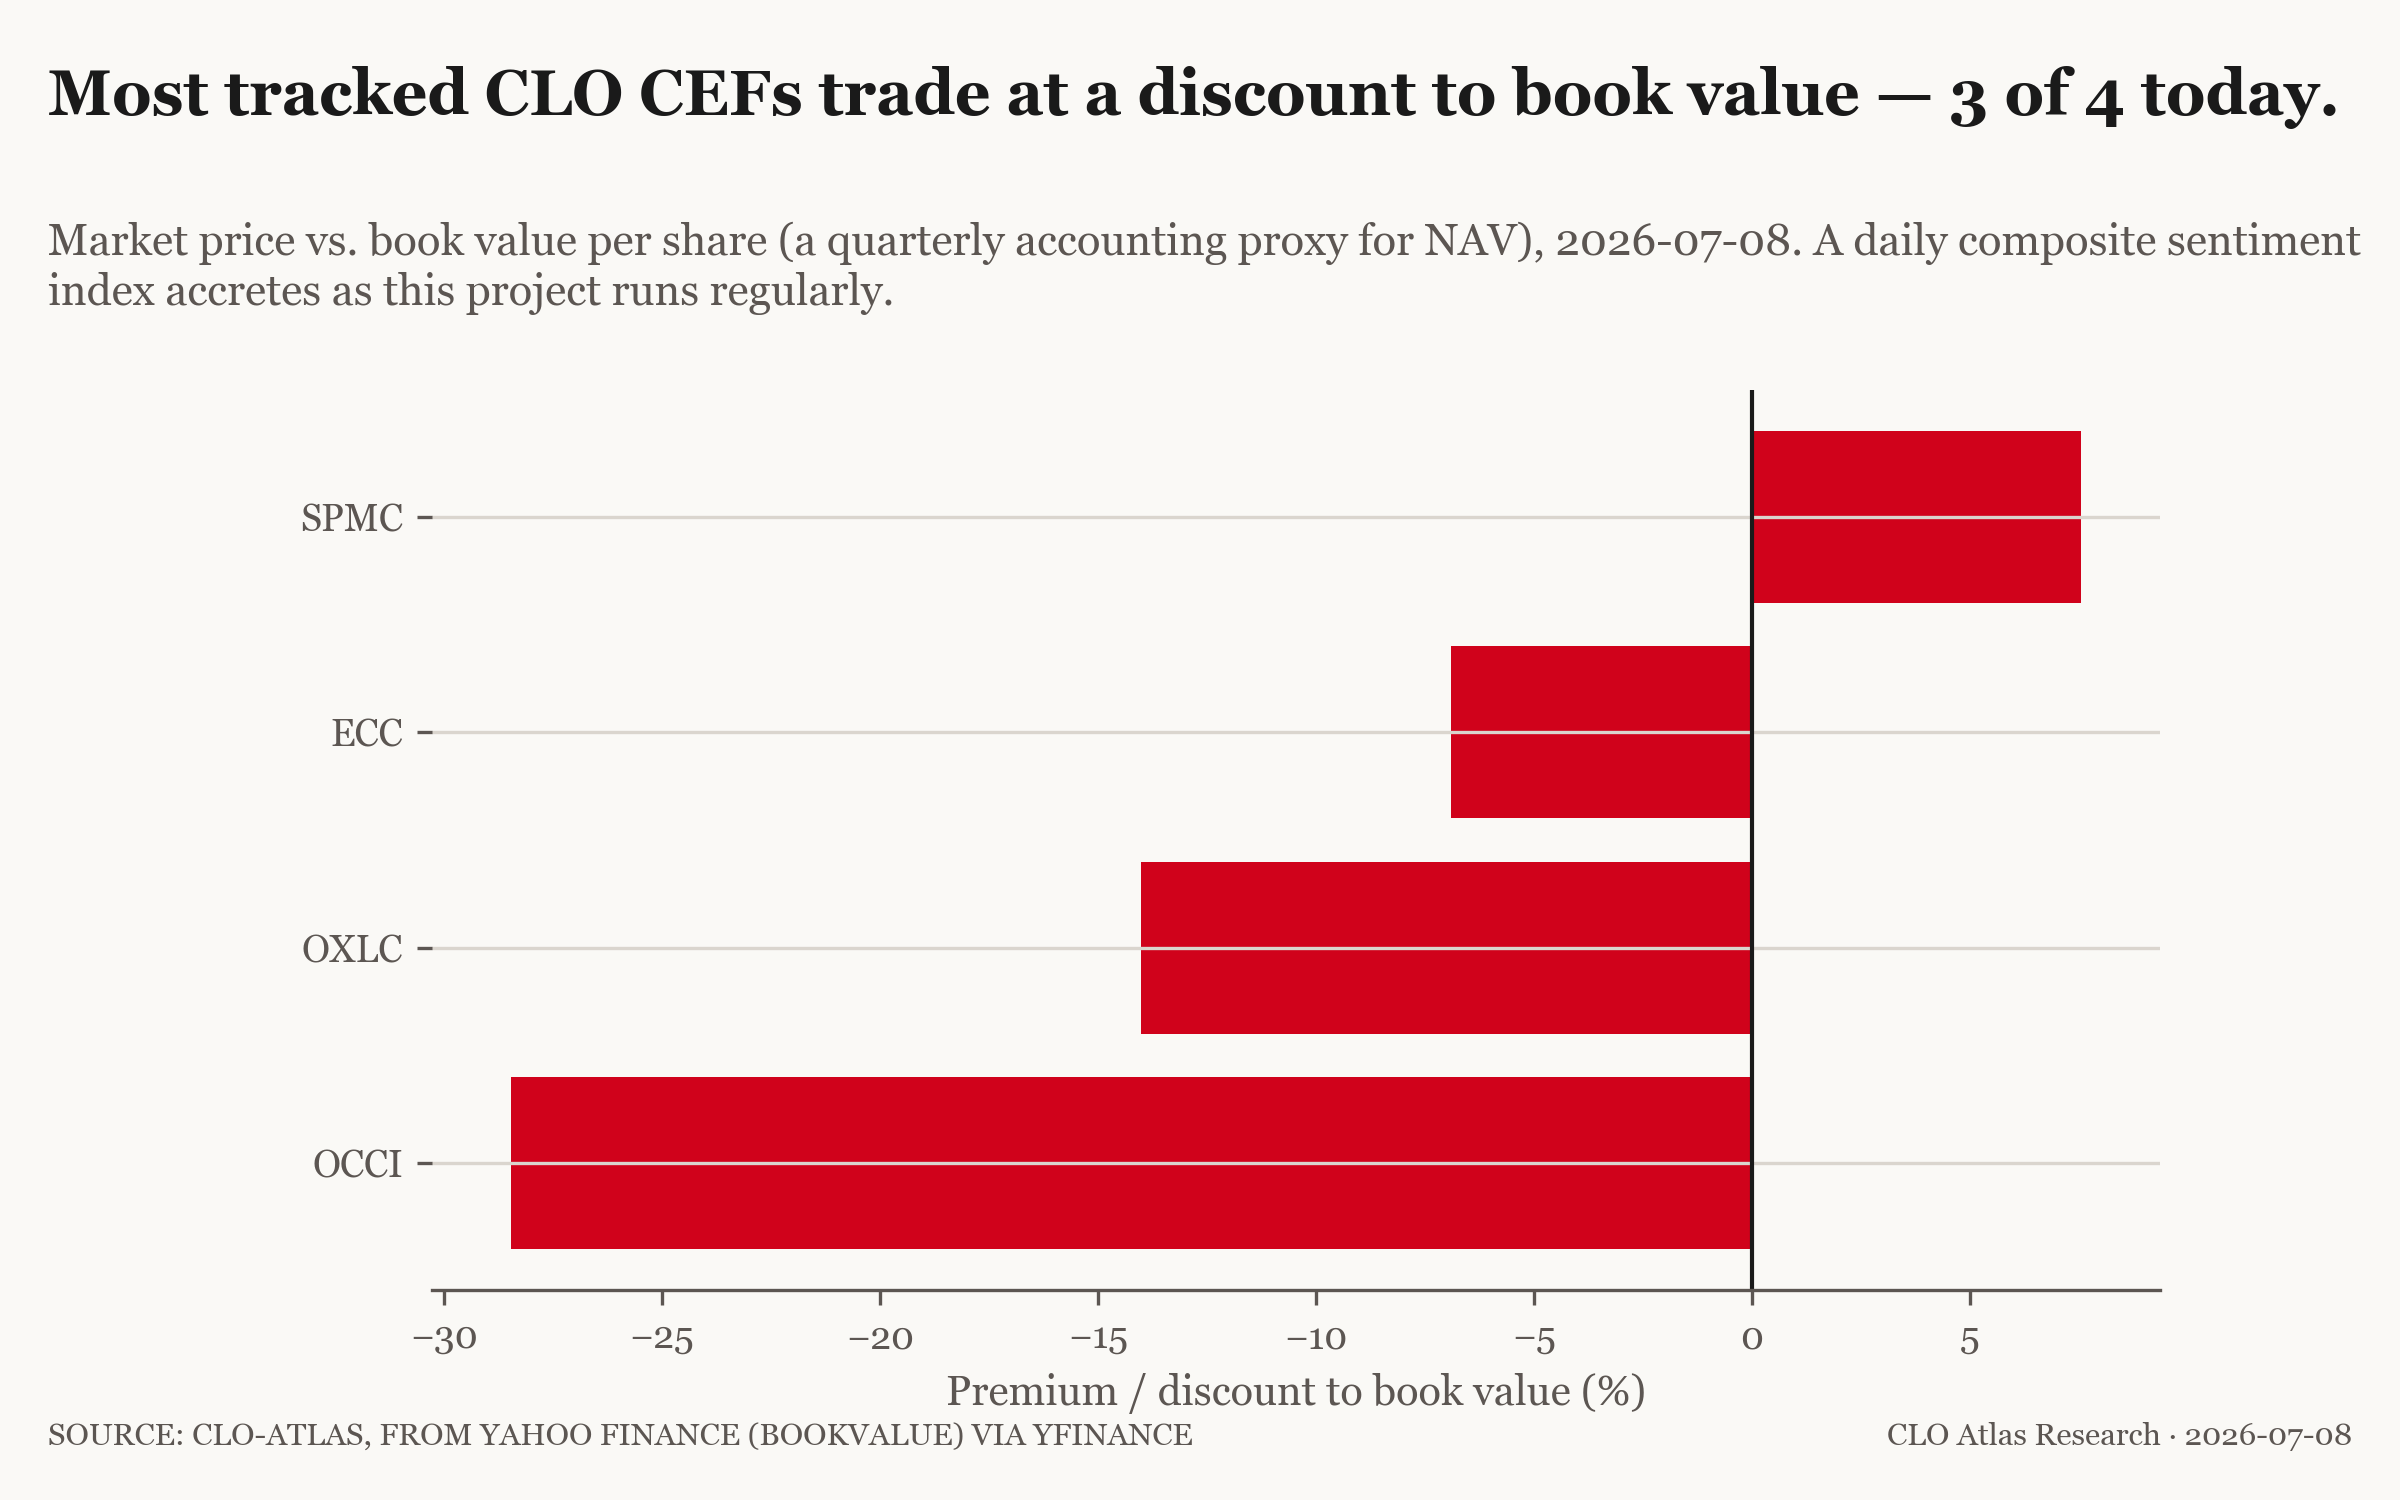

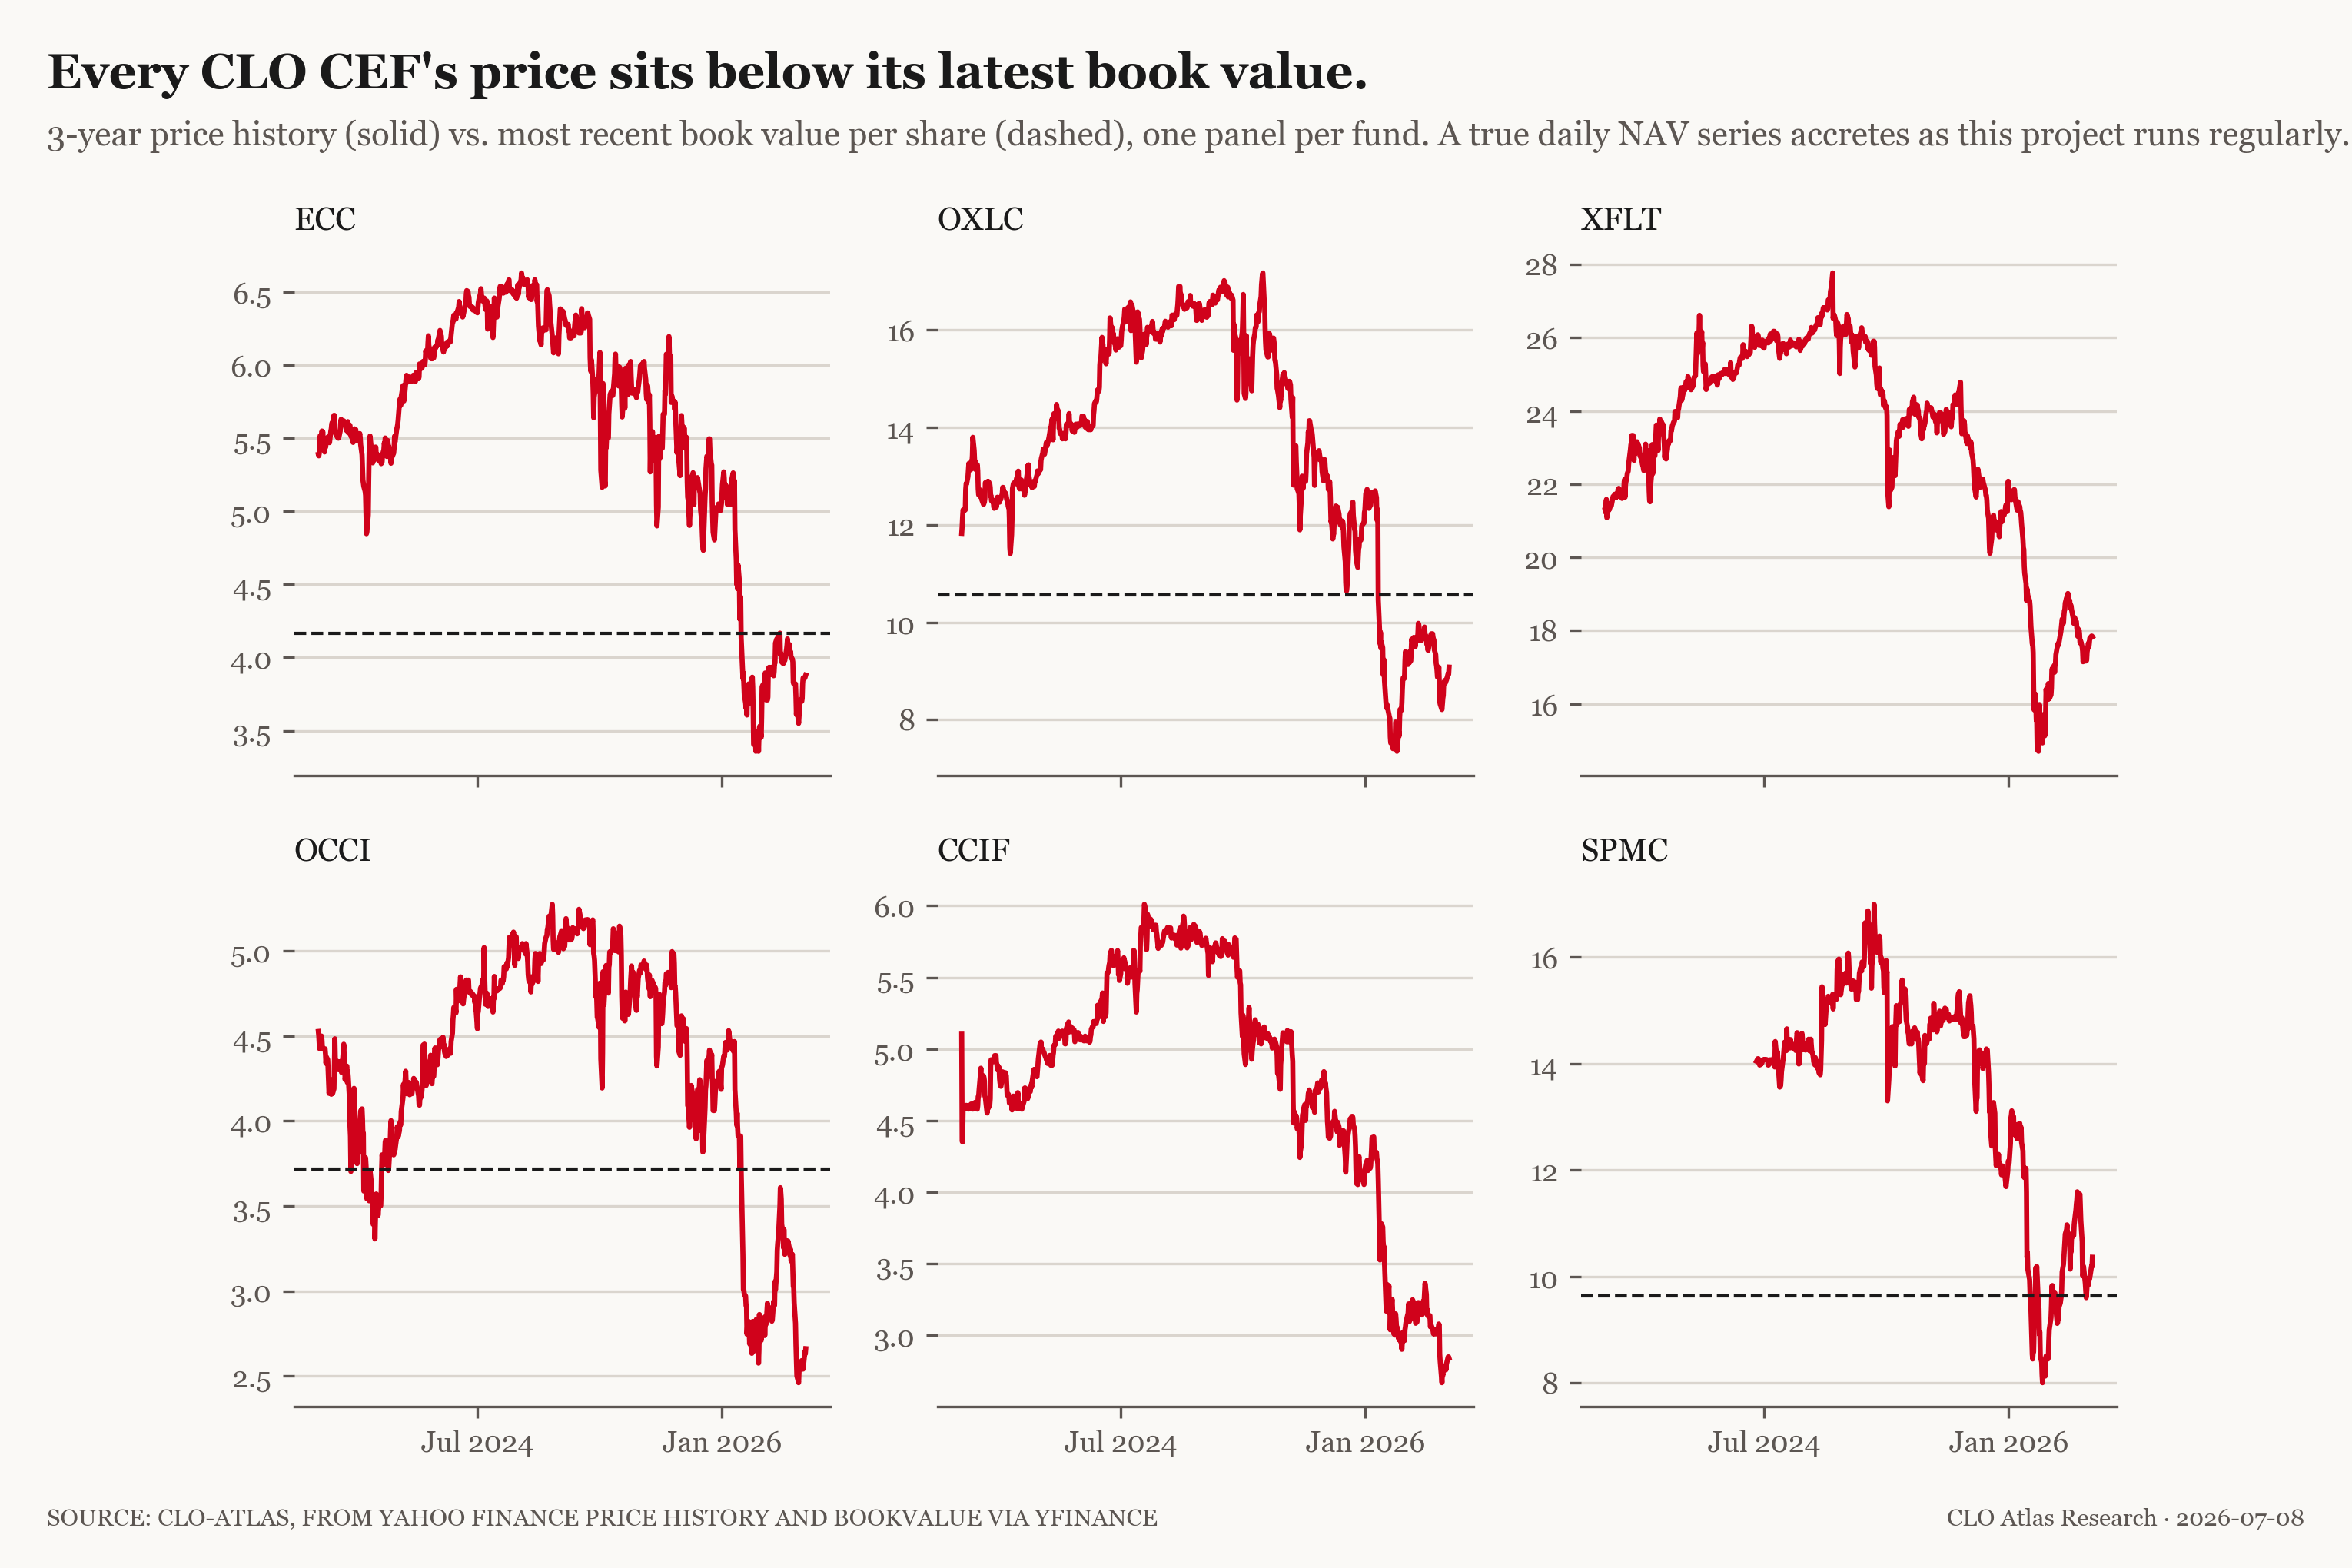

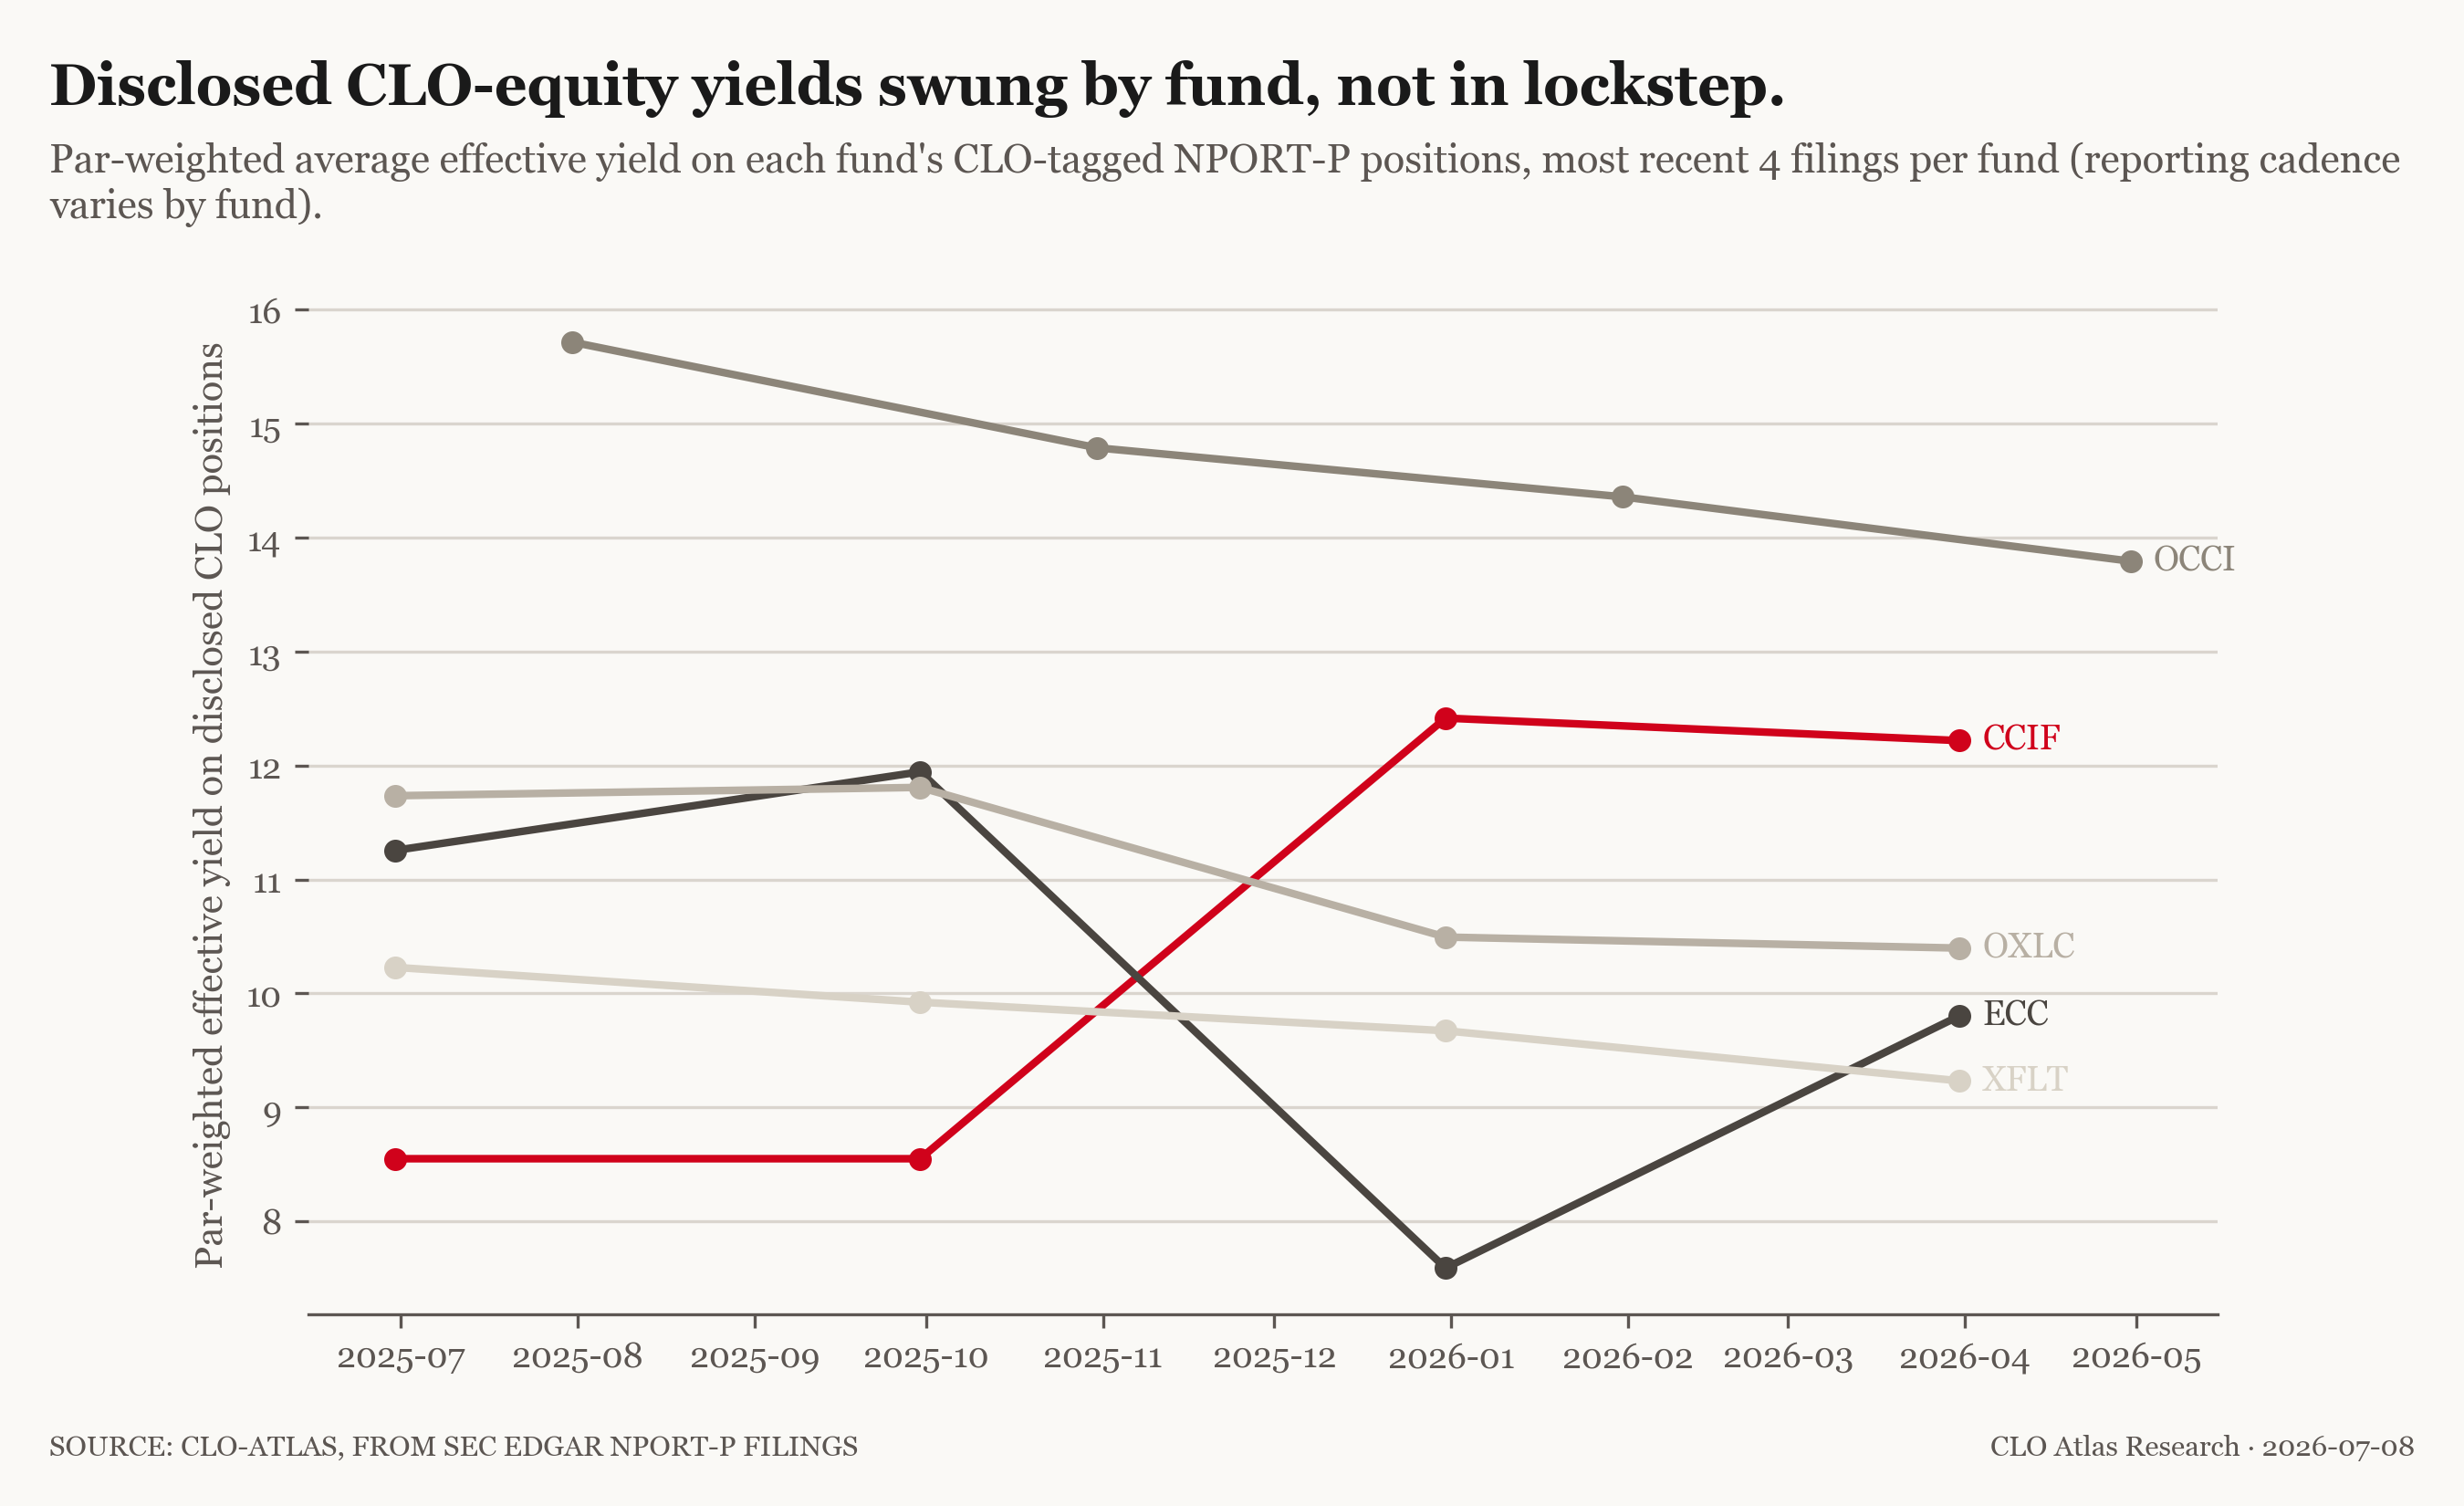

In [5]:
for name in [
    "viz_distribution_changes", "viz_current_discount_snapshot",
    "viz_price_vs_book_reference", "viz_weighted_yield_trend",
]:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")